In [2]:
import pandas as pd
import numpy as np
import config
import os

from get_data import DataLoader


DataLoader = DataLoader(config.DATA_PATH)
df = DataLoader.load_data()

## Question 1 [4 marks]
Present and discuss a single table (Table 1) summarizing the baseline characteristics of the individuals (first observation per individual). Stratify the table by sex.

categorical = ['cohab','hw_all','sex']
continuous  = ['satisfaction','age_marriage','income']

In [12]:
# -----------------------------
# 1. Baseline dataset
# -----------------------------
df_baseline = (
    df
    .sort_values(["id", "obs_time"])
    .groupby("id", as_index=False)
    .first()
)

# Optional: inspect coding of sex
print(df_baseline["sex"].value_counts(dropna=False))


# -----------------------------
# 2. Helper functions
# -----------------------------
def summarize_cont(df, var, by="sex", digits=2):
    out = df.groupby(by)[var].agg(["mean", "std"])
    return out.apply(
        lambda row: f"{row['mean']:.{digits}f} ({row['std']:.{digits}f})",
        axis=1
    )

def summarize_cat(df, var, by="sex", digits=1):
    counts = pd.crosstab(df[var], df[by], dropna=False)
    perc = pd.crosstab(df[var], df[by], normalize="columns", dropna=False) * 100
    return counts.astype(int).astype(str) + " (" + perc.round(digits).astype(str) + "%)"


# -----------------------------
# 3. Build continuous rows
# -----------------------------
sex_levels = list(df_baseline["sex"].dropna().unique())

table1_rows = []

for label, var in [
    ("Age at marriage", "age_marriage"),
    ("Income", "income"),
]:
    s = summarize_cont(df_baseline, var)
    row = {"Variable": label}
    for sex in sex_levels:
        row[str(sex)] = s.get(sex, "")
    table1_rows.append(row)


# -----------------------------
# 4. Build categorical rows
# -----------------------------
def add_categorical_block(table_rows, df, var, block_name, by="sex"):
    cat_summary = summarize_cat(df, var, by=by)

    # block header
    header_row = {"Variable": block_name}
    for col in cat_summary.columns:
        header_row[str(col)] = ""
    table_rows.append(header_row)

    # category rows
    for level in cat_summary.index:
        row = {"Variable": f"  {level}"}
        for col in cat_summary.columns:
            row[str(col)] = cat_summary.loc[level, col]
        table_rows.append(row)

add_categorical_block(table1_rows, df_baseline, "cohab", "Cohabitation")
add_categorical_block(table1_rows, df_baseline, "hw_all", "Housework allocation")


# -----------------------------
# 5. Final Table 1
# -----------------------------
table1 = pd.DataFrame(table1_rows)


table1

sex
female    285
male      209
Name: count, dtype: int64


,Variable,female,male
0,Age at marriage,27.31 (4.70),29.59 (4.85)
1,Income,32502.84 (18539.35),30976.49 (16881.02)
2,Cohabitation,,
3,0,42 (14.7%),25 (12.0%)
4,1,243 (85.3%),184 (88.0%)
5,Housework allocation,,
6,0,108 (37.9%),196 (93.8%)
7,1,177 (62.1%),13 (6.2%)


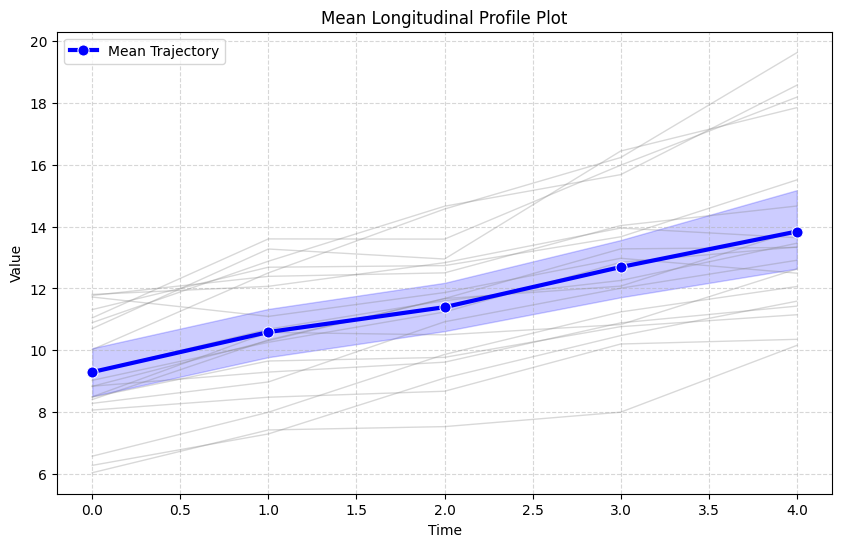

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Sample Longitudinal Data
np.random.seed(42)
subjects = 20
time_points = [0, 1, 2, 3, 4]
data = []

for s in range(subjects):
    # Create a random trajectory for each subject
    start_value = np.random.normal(10, 2)
    slope = np.random.normal(1, 0.5)
    for t in time_points:
        value = start_value + slope * t + np.random.normal(0, 0.5)
        data.append({'subject': s, 'time': t, 'value': value})

df = pd.DataFrame(data)

# 2. Plotting
plt.figure(figsize=(10, 6))

# Plot individual trajectories (Spaghetti plot) with low alpha (transparency)
sns.lineplot(data=df, x='time', y='value', units='subject', estimator=None, 
             color='gray', alpha=0.3, linewidth=1, legend=False)

# Plot the Mean Profile
sns.lineplot(data=df, x='time', y='value', estimator='mean', 
             color='blue', linewidth=3, marker='o', markersize=8, label='Mean Trajectory')

plt.title('Mean Longitudinal Profile Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()
